# Loading the model

In [8]:
import os
import torch
import numpy as np
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, random_split
from torchsummary import summary
import torch.nn as nn
import torch.optim as optim
from logger import logging
from Project import Project
from poutyne.framework import Model
from LymphoMNIST.LymphoMNIST import LymphoMNIST
import LymphoMNIST as info
from utils import device

import numpy as np
import torchvision.transforms as T
from imgaug import augmenters as iaa
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split


def get_dataloaders(
        train_ds,
        val_ds,
        split=(0.5, 0.5),
        batch_size=64,
        *args, **kwargs):
    """
    This function returns the train, val and test dataloaders.
    """

    # now we want to split the val_ds in validation and test
    lengths = np.array(split) * len(val_ds)
    lengths = lengths.astype(int)
    left = len(val_ds) - lengths.sum()
    # we need to add the different due to float approx to int
    lengths[-1] += left

    val_ds, test_ds = random_split(val_ds, lengths.tolist())
    logging.info(f'Train samples={len(train_ds)}, Validation samples={len(val_ds)}, Test samples={len(test_ds)}')

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, *args, **kwargs)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)

    return train_dl, val_dl, test_dl


class FilteredLymphoMNIST(Dataset):
    def __init__(self, original_dataset, labels_to_keep):
        self.original_dataset = original_dataset
        # Filter indices based on labels_to_keep
        self.indices = [i for i, (_, label) in enumerate(original_dataset) if label in labels_to_keep]

    def __getitem__(self, index):
        # Map the current index to the index of the original dataset
        original_index = self.indices[index]
        return self.original_dataset[original_index]

    def __len__(self):
        return len(self.indices)


class ConvertToRGB:
    """
    Convert 1-channel tensors to 3-channel tensors by duplicating the channel 3 times.
    """
    def __call__(self, tensor):
        # Check if the tensor is 1-channel (C, H, W) where C == 1
        if tensor.shape[0] == 1:
            # Duplicate the channel 3 times
            tensor = tensor.repeat(3, 1, 1)
        return tensor



class ImgAugTransform:
    """
    Wrapper to allow imgaug to work with Pytorch transformation pipeline, modified for 1-channel images.
    """
    def __init__(self):
        self.aug = iaa.Sequential([
            iaa.Sometimes(0.2, iaa.GaussianBlur(sigma=(0, 3.0))),
            iaa.Sometimes(0.8, iaa.Sequential([
                iaa.Fliplr(0.5),
                iaa.Flipud(0.5)
            ])),
            iaa.Sometimes(0.5, iaa.Sequential([
                iaa.Crop(percent=(0.1, 0.2))
            ])),
            iaa.LinearContrast((0.75, 1.5)),
            iaa.Affine(rotate=(-20, 20), mode='symmetric'),
            iaa.Sometimes(0.8, iaa.Affine(
                scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
                translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
                rotate=(-25, 25),
                shear=(-8, 8)
            )),
            iaa.AddToHueAndSaturation(value=(-10, 10), per_channel=True)
        ])

    def __call__(self, img):
        # Convert 1-channel images to 3-channel images for augmentation
        if img.mode == 'L':
            img = img.convert("RGB")
        img = np.array(img)
        img = self.aug.augment_image(img)
        # Convert back to 1-channel image if originally it was
        img = Image.fromarray(img).convert('L')
        return img

im_size = 64

val_transform = T.Compose([
    T.Resize((im_size, im_size)),
    T.ToTensor(),
    T.Normalize([0.4819], [0.1484]),  # Adjusted for 1-channel
    ConvertToRGB()
])



# Model setup
params = {'lr': 5e-5, 'batch_size': 16, 'epochs': 1000, 'model': "teacher_final"}
labels_to_keep = [0, 1]  # Specify labels to keep
# Load datasets
train_ds = FilteredLymphoMNIST(LymphoMNIST(root='./dataset', train=True, download=True, transform=val_transform, num_classes=3), labels_to_keep)
test_ds = FilteredLymphoMNIST(LymphoMNIST(root='./dataset', train=False, download=True, transform=val_transform, num_classes=3), labels_to_keep)

# Initialize dataloaders
train_dl, val_dl, test_dl = get_dataloaders(train_ds, test_ds, split=(0.5, 0.5), batch_size=params['batch_size'], num_workers=4)

Dataset already exists. Skipping download.
Dataset already exists. Skipping download.


2024-05-28 14:54:42,420 - [INFO] - Train samples=40800, Validation samples=5100, Test samples=5100


In [15]:
# Load and modify a pre-trained ResNet50 model
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50.fc = nn.Linear(resnet50.fc.in_features, 2)  # Adjust for the number of classes
# model_weights_path = 'checkpoint/10 March 21:26-modelteacher_final-long.pt'
model_weights_path = 'checkpoint/final_version/teacher_97_percent.pt'
# model_weights_path ='checkpoint/13 May 11:00-modelteacher_final-balanced-short.pt'
resnet50.load_state_dict(torch.load(model_weights_path, map_location=device))
cnn = resnet50.to(device)

# Summary
summary(cnn, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]           4,096
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11          [-1, 256, 16, 16]          16,384
      BatchNorm2d-12          [-1, 256, 16, 16]             512
           Conv2d-13          [-1, 256, 16, 16]          16,384
      BatchNorm2d-14          [-1, 256,

# Detail results

In [16]:
# print cnn model classification report
from sklearn.metrics import classification_report

cnn.eval()
y_true = []
y_pred = []
for inputs, labels in test_dl:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = cnn(inputs)
    _, predicted = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1938
           1       0.96      0.98      0.97      3162

    accuracy                           0.96      5100
   macro avg       0.96      0.96      0.96      5100
weighted avg       0.96      0.96      0.96      5100



# Train vs validation accuracy

In [ ]:
import json
import numpy as np

# Replace 'path/to/your/file.json' with the actual path to your JSON file
json_file_path = './paper_viz/teacher/train_acc.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    data = json.load(file)


# Extract 'x' and 'y' values
train_x_values = data[0]['x']
train_y_values = data[0]['y']

# Convert lists to NumPy arrays
train_x_values = np.array(train_x_values)
train_y_values = np.array(train_y_values)

In [ ]:
import json
import numpy as np

# Replace 'path/to/your/file.json' with the actual path to your JSON file
json_file_path = './paper_viz/teacher/val_acc.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    data = json.load(file)


# Extract 'x' and 'y' values
val_x_values = data[0]['x']
val_y_values = data[0]['y']

# Convert lists to NumPy arrays
val_x_values = np.array(val_x_values)
val_y_values = np.array(val_y_values)

In [ ]:
# find a specific value index
index = np.where(train_x_values == 200)
print(index)


In [ ]:

import matplotlib.pyplot as plt

# colors2 = ['#7bbbe0', '#e9a001']
colors2 = ['#1f77b4', '#ff7f0e']

# Plot the data
fig, ax = plt.subplots(figsize=(8,3.5), dpi= 300)
plt.plot(train_x_values[:70], train_y_values[:70], color = colors2[0], lw=2, label='Train Accuracy')
plt.plot(val_x_values[:70], val_y_values[:70], color = colors2[1], lw=2,label='Validation Accuracy')
plt.plot(train_x_values[70], train_y_values[70], 'o', markerfacecolor = colors2[0], markersize=10, markeredgewidth=0.0)
plt.plot(val_x_values[70], val_y_values[70], 'o', markerfacecolor = colors2[1], markersize=10, markeredgewidth=0.0)


font_size=20
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50



# Set tick parameters
ax.tick_params(axis='both', length=10, width=1.5, color= 'gray', direction='in')

# Turn off the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the color of the axes
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')




# plt.title('Training vs Validation Accuracy', fontsize=font_size)
plt.xlabel('Epochs', fontsize=font_size)
plt.ylabel('Accuracy', fontsize=font_size)
plt.legend()

image_name = "paper_viz/teacher/Train_vs_validation_accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


# ROC

In [3]:
cnn.eval()  # set the model to evaluation mode

# Variable for model predictions and true labels
y_pred = []
y_true = []

roc_data = {"train":[], 'val':[]}


with torch.no_grad():
    for image, target in train_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['train'] = [fpr, tpr, roc_auc]


with torch.no_grad():
    for image, target in val_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['val'] = [fpr, tpr, roc_auc]


In [ ]:
print(roc_data)

{'train': [array([0.        , 0.        , 0.        , ..., 0.98131579, 0.98131579,
       1.        ]), array([0.        , 0.006875  , 0.01289062, ..., 0.99996094, 1.        ,
       1.        ]), 0.9986977577611018], 'val': [array([0.        , 0.        , 0.        , ..., 0.99970842, 0.99970842,
       1.        ]), array([0.        , 0.00674736, 0.01286867, ..., 0.99996522, 1.        ,
       1.        ]), 0.9980795861350571]}


<Figure size 640x480 with 0 Axes>

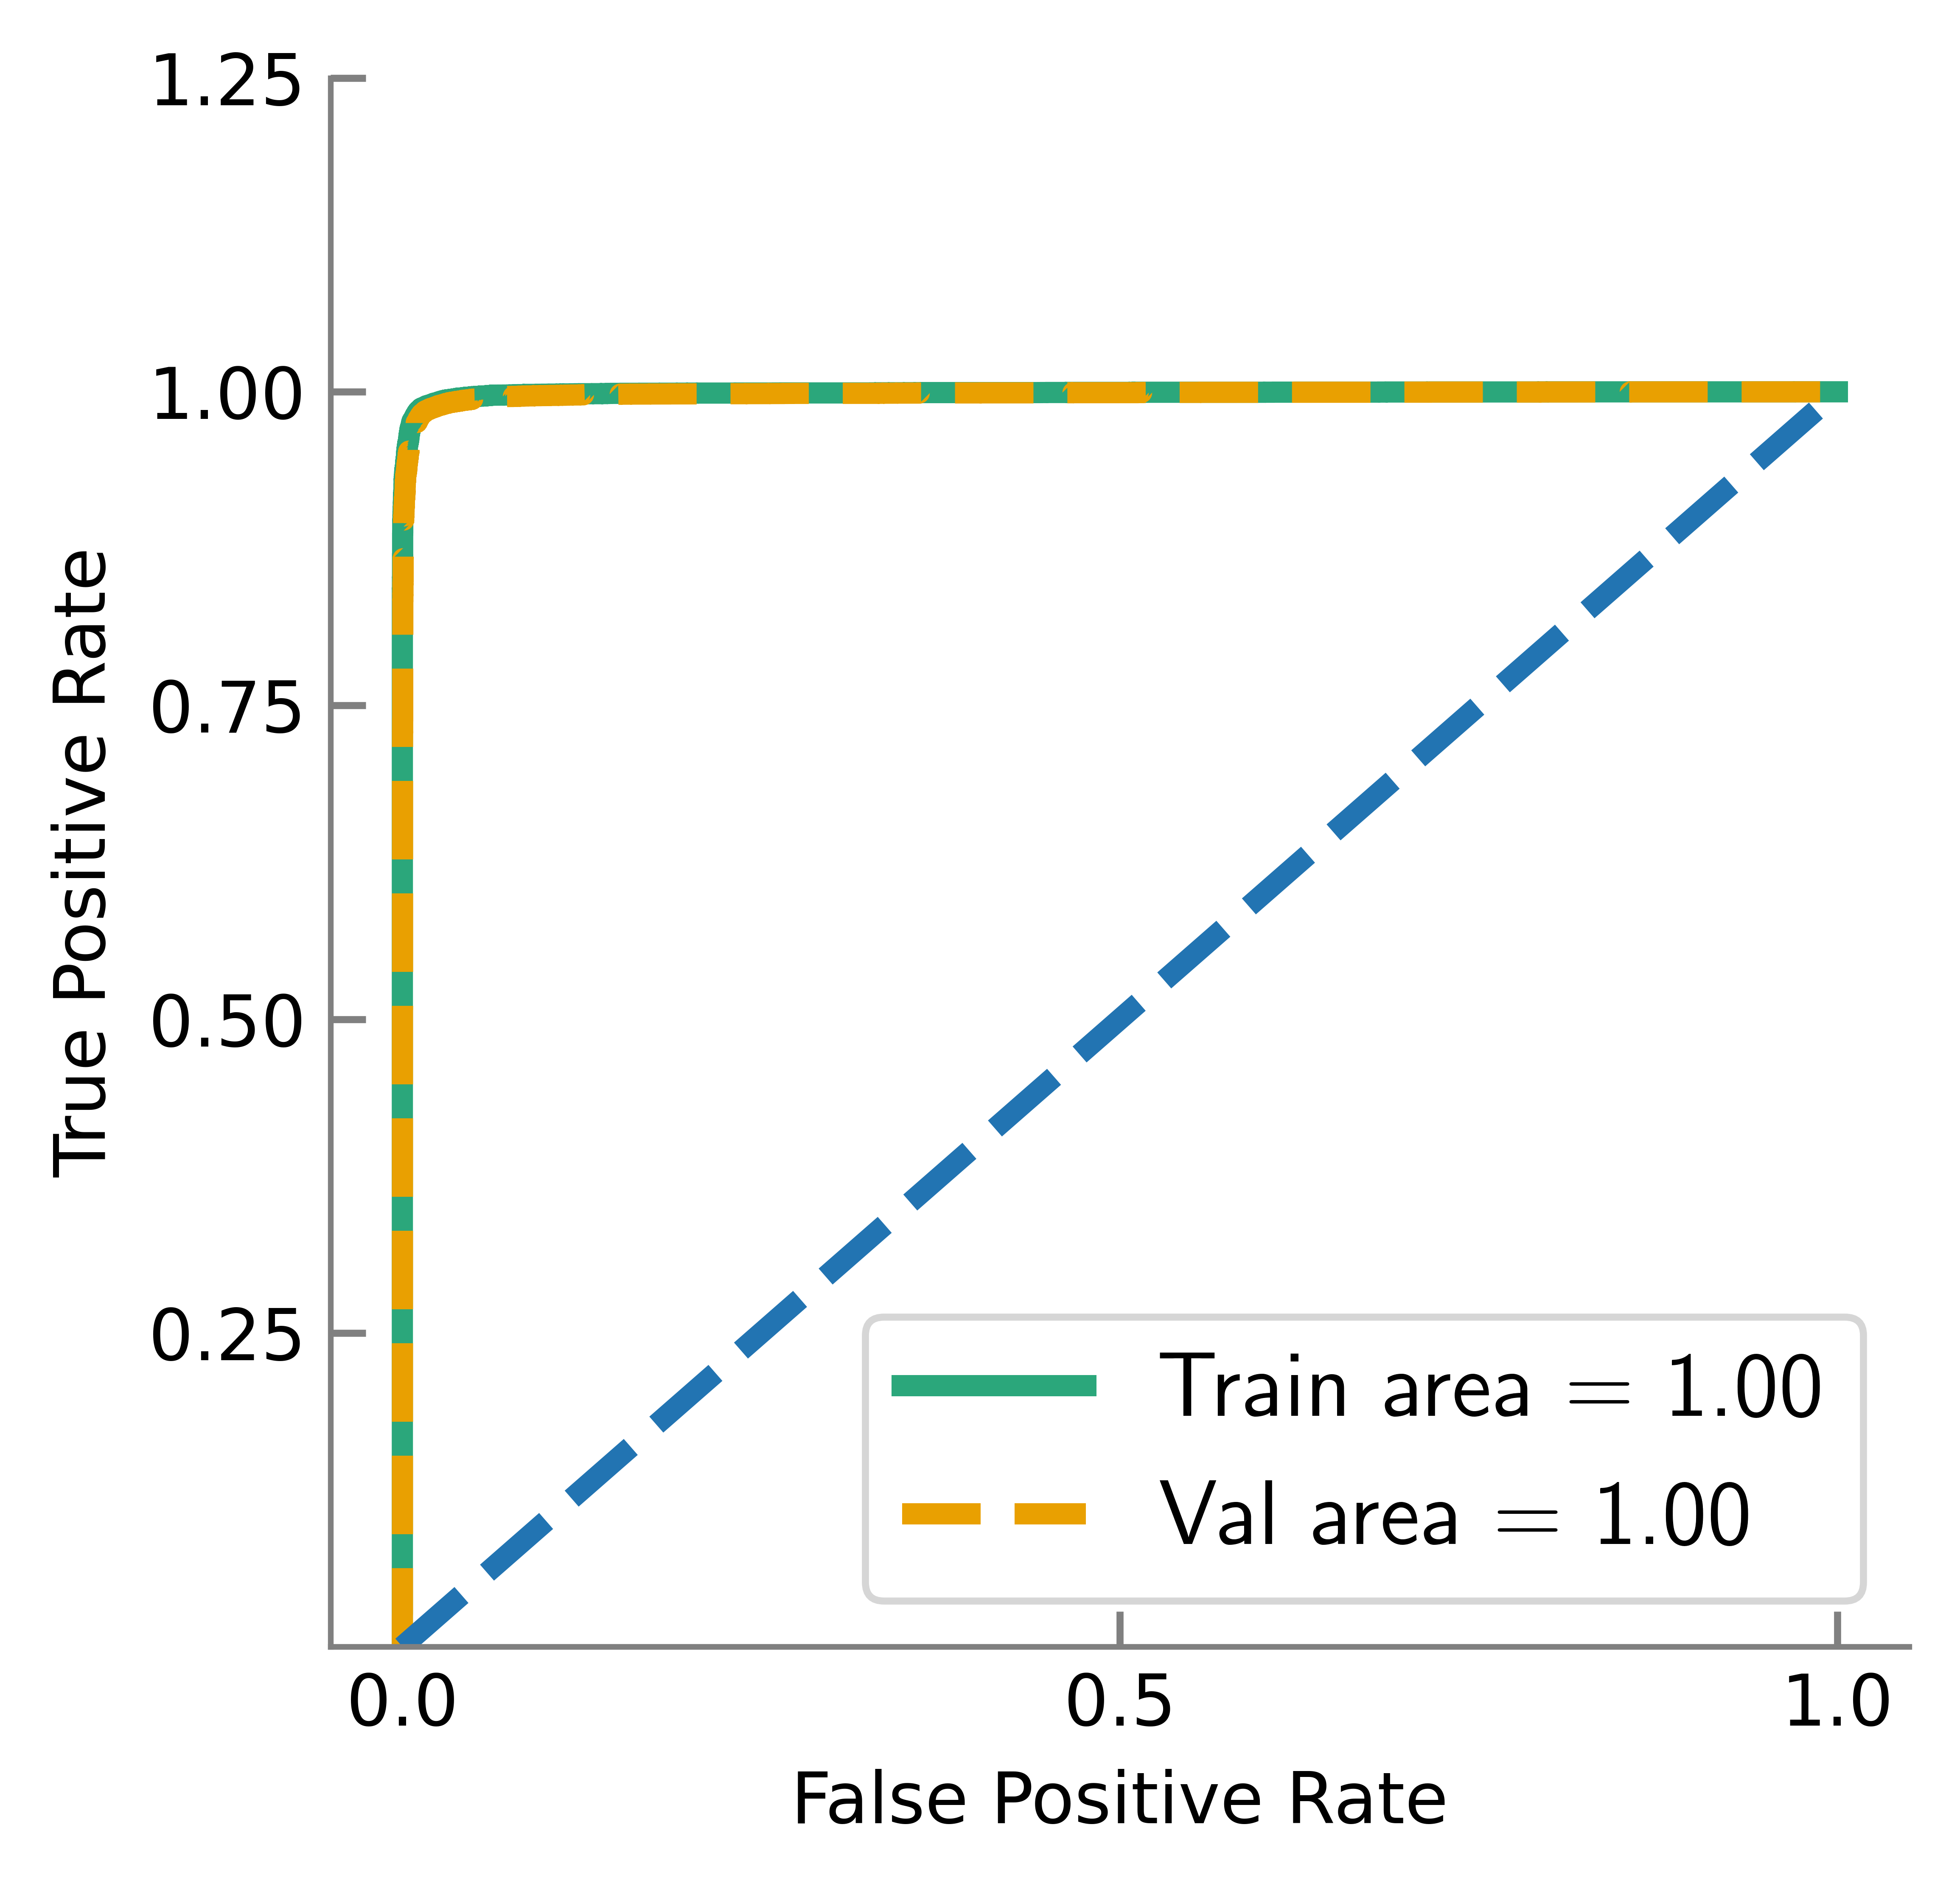

In [4]:
import matplotlib.pyplot as plt

# Plot ROC curve
plt.figure()
lw = 3  # line width
multiplier = 0.9
colors3 = ['#2ba77b', '#e9a001', '#2274b2']

fig, ax = plt.subplots(figsize=(4,4), dpi= 1200)

fpr, tpr, roc_auc = roc_data['train']

# fpr, tpr, roc_auc = np.array(fpr)*multiplier, np.array(tpr)*multiplier, roc_auc*multiplier

plt.plot(fpr, tpr, '-', color=colors3[0], lw=lw, label='Train area = %0.2f' % roc_auc)

fpr, tpr, roc_auc = roc_data['val']
# fpr, tpr, roc_auc = np.array(fpr)*multiplier, np.array(tpr)*multiplier, roc_auc*multiplier
plt.plot(fpr, tpr, '--', color=colors3[1], lw=lw, label='Val area = %0.2f' % roc_auc)

plt.plot([0, 1], [0, 1], color=colors3[2], lw=lw, linestyle='--')
# plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])



# plt.legend(loc="lower right")
# plt.show()



font_size=20
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50



# Set tick parameters
ax.tick_params(axis='both', length=5, width=1, color= 'gray', direction='in')

# Turn off the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the color of the axes
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic example')
plt.legend(fontsize=font_size*0.65, loc="lower right")


# Modify x and y tick labels
xticks = ax.get_xticks()
yticks = ax.get_yticks()

# Remove the first tick
# if len(xticks) > 1:
#     ax.set_xticks(xticks[1:])
if len(yticks) > 1:
    ax.set_yticks(yticks[1:])

# plt.show()
image_name = "paper_viz/teacher/CNN_ROC"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


# Confusion matrix

## Test data

In [10]:
y_pred = []
y_true = []

# Set model to evaluation mode
cnn.eval()

with torch.no_grad():
    for image, target in test_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        target = target.data.cpu().numpy()
        y_true.extend(target) # Save target

/tmp/ipykernel_1580406/781973988.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = plt.cm.get_cmap('rocket')


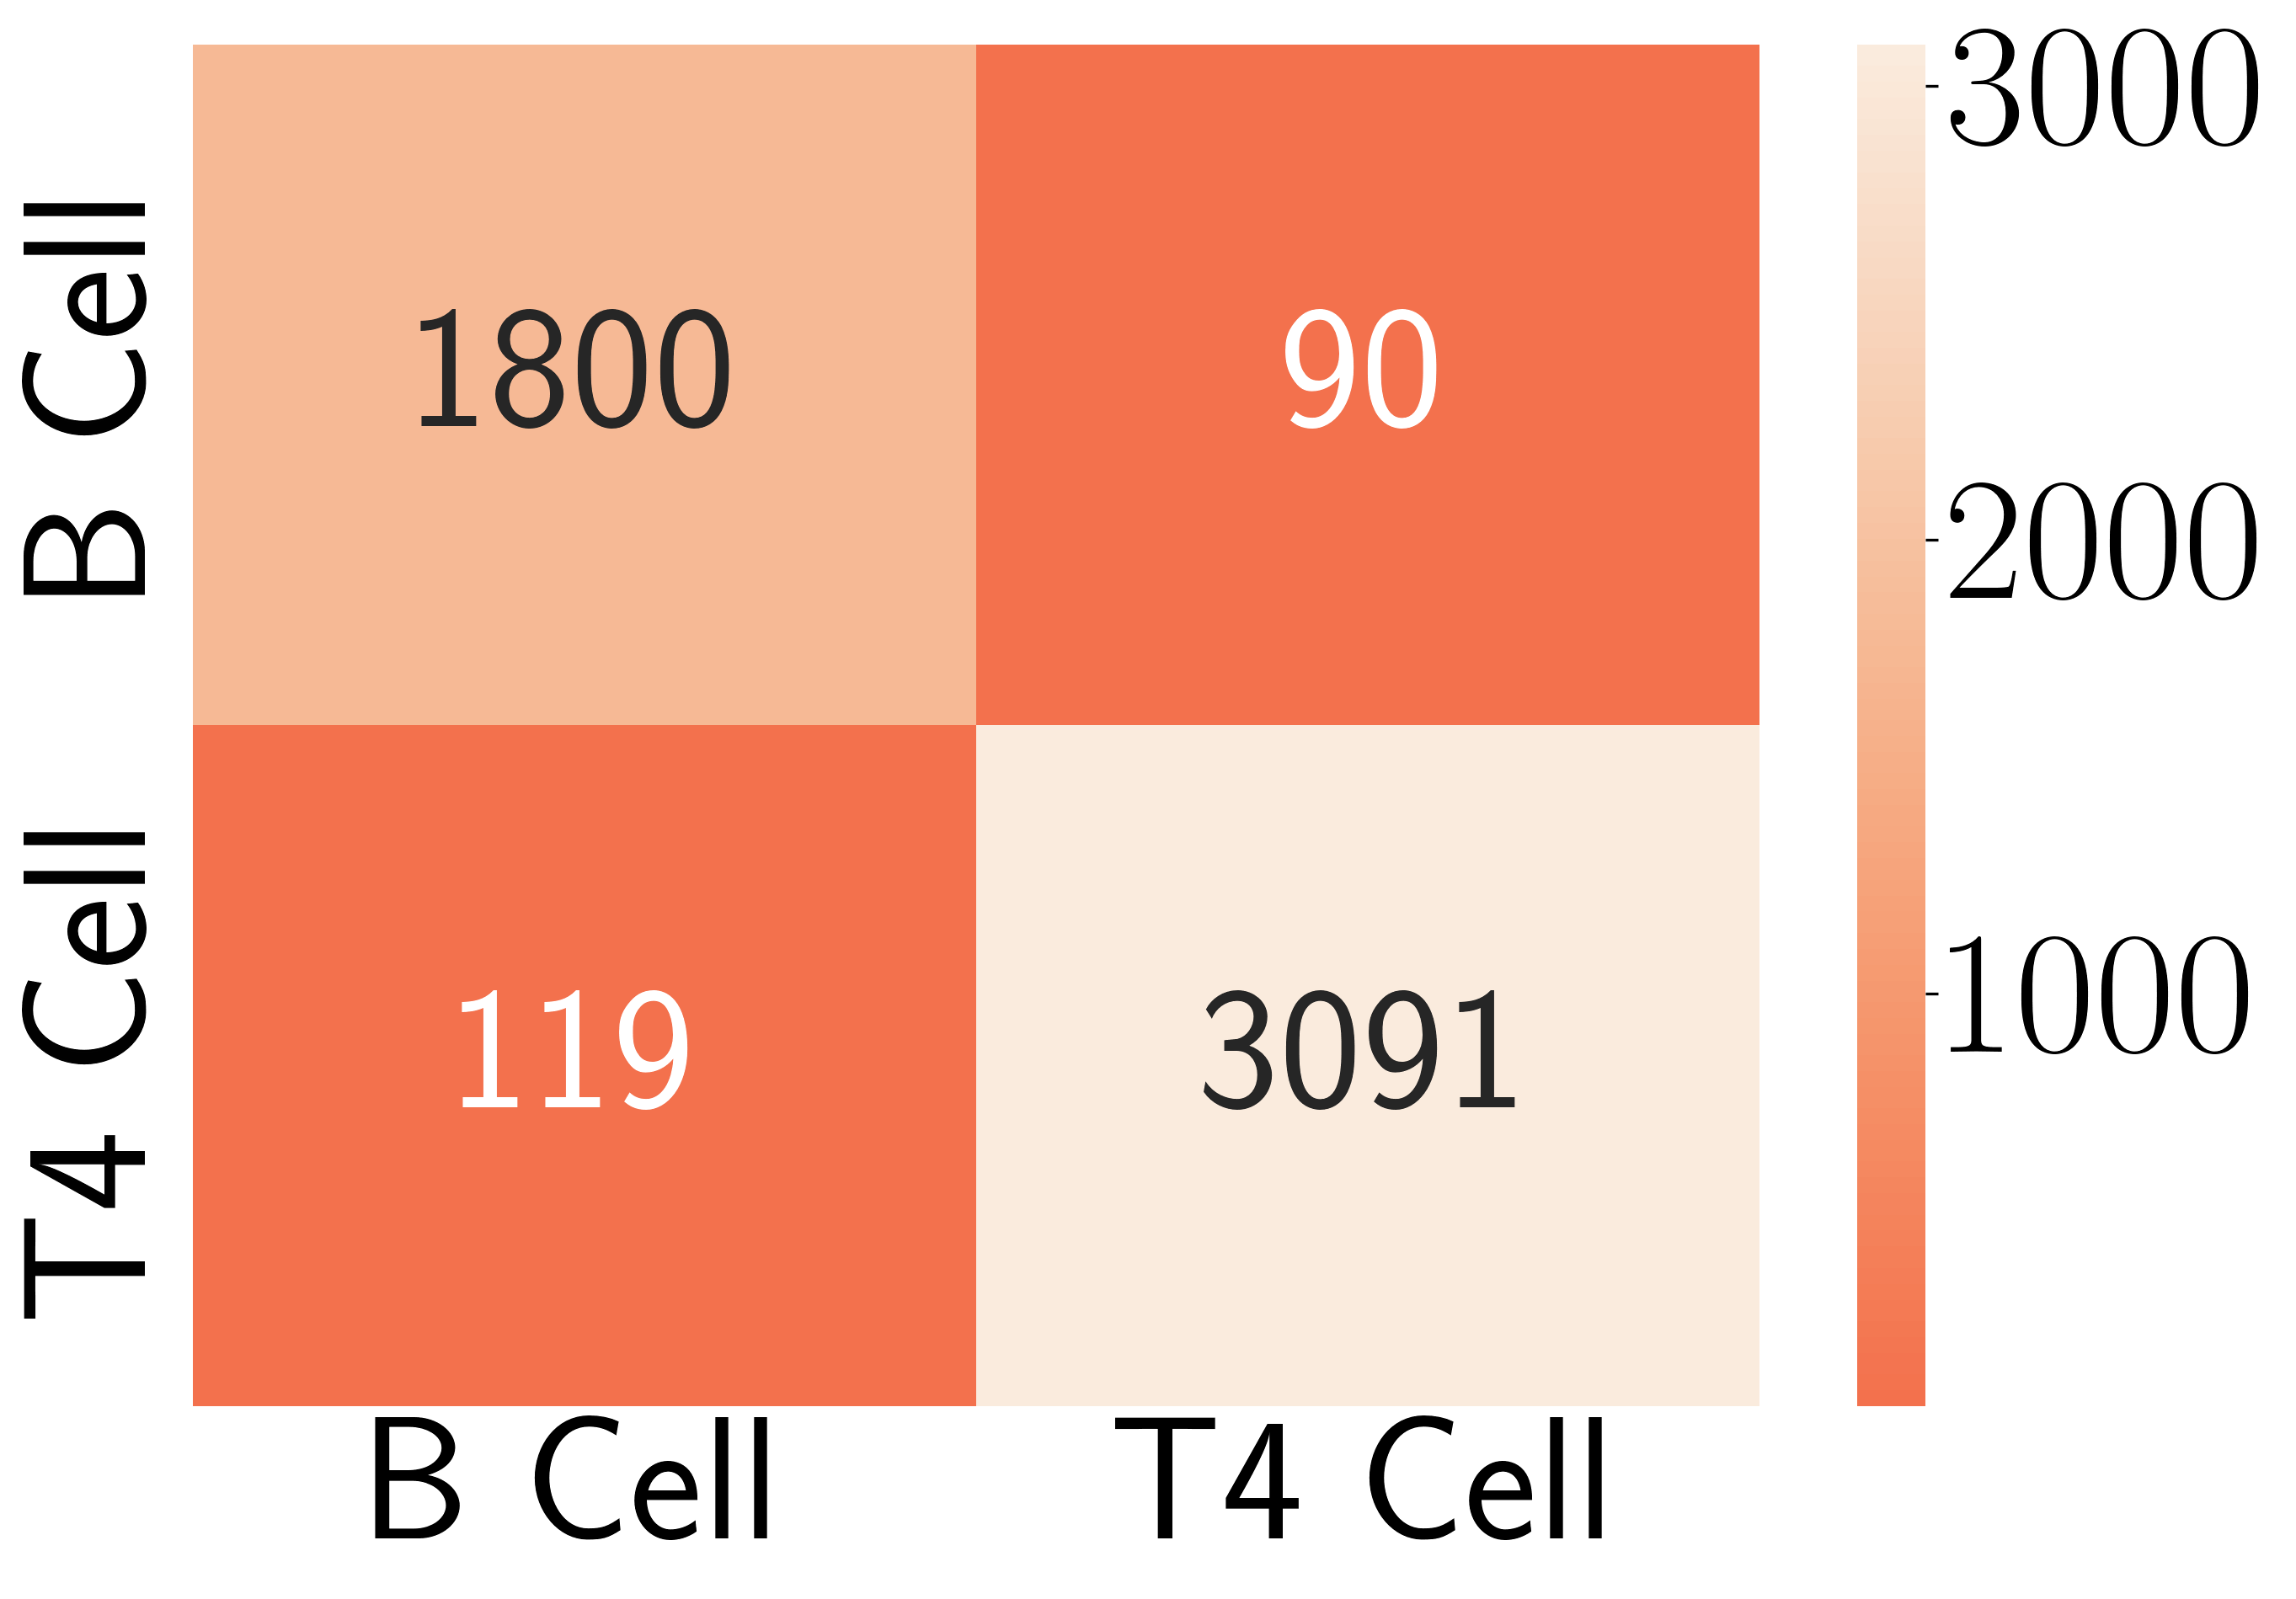

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

# Define tick labels
labels = ["B Cell", "T4 Cell"]

fig, ax = plt.subplots(figsize=(10,7), dpi= 300)

original_cmap = plt.cm.get_cmap('rocket')
# create new colormap using the top 40%
new_cmap = plt.cm.colors.ListedColormap(original_cmap(np.linspace(0.7, 1, 256)))


ax = sns.heatmap(cm, annot=True, fmt="d", cmap=new_cmap, xticklabels=labels, yticklabels=labels)
# Set tick parameters
ax.tick_params(axis='both', length=5, width=0.0, color= 'gray', direction='in')


image_name = "paper_viz/teacher/Confusion_test"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [11]:


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

# Calculate accuracy
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


### Train data

In [18]:
y_pred = []
y_true = []

with torch.no_grad():
    for image, target in train_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        target = target.data.cpu().numpy()
        y_true.extend(target) # Save target

/tmp/ipykernel_1580406/3991880258.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = plt.cm.get_cmap('rocket')


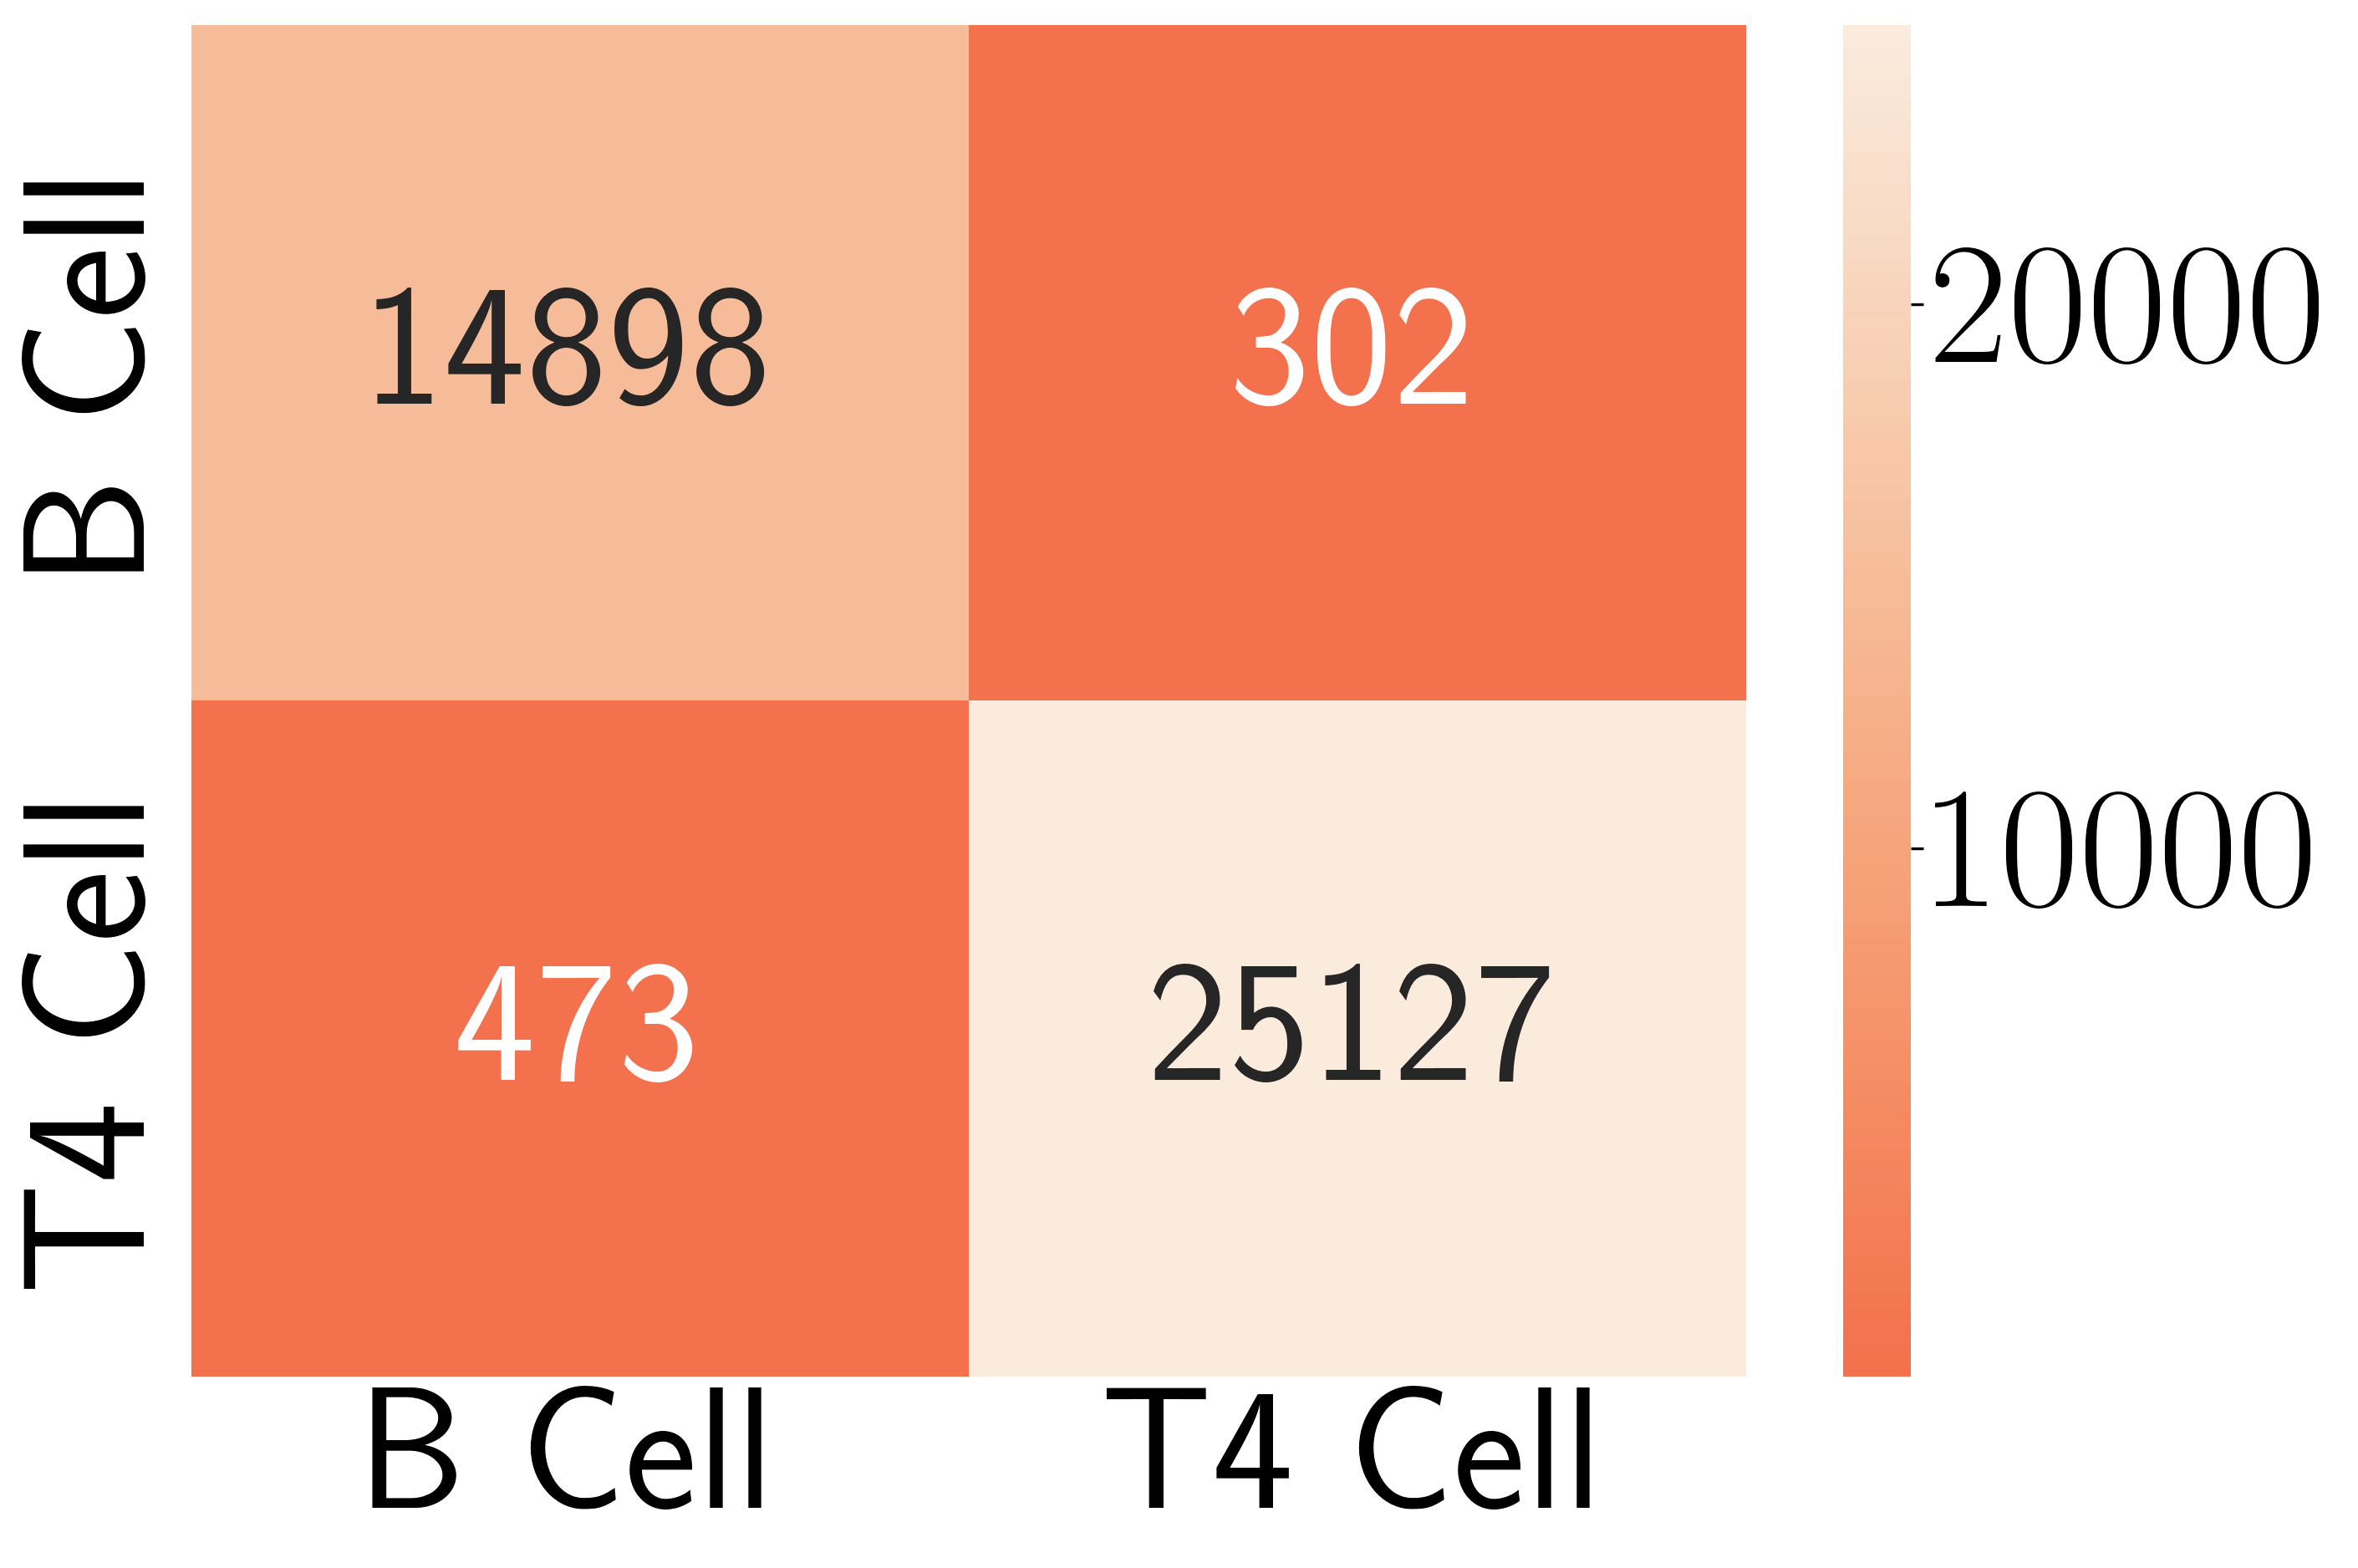

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

# Define tick labels
labels = ["B Cell", "T4 Cell"]

fig, ax = plt.subplots(figsize=(10,7), dpi= 300)

original_cmap = plt.cm.get_cmap('rocket')
# create new colormap using the top 40%
new_cmap = plt.cm.colors.ListedColormap(original_cmap(np.linspace(0.7, 1, 256)))


ax = sns.heatmap(cm, annot=True, fmt="d", cmap=new_cmap, xticklabels=labels, yticklabels=labels)
# Set tick parameters
ax.tick_params(axis='both', length=5, width=0.0, color= 'gray', direction='in')


image_name = "paper_viz/teacher/Confusion_train"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
# Calculate accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.38


## val data

In [17]:
y_pred = []
y_true = []

with torch.no_grad():
    for image, target in val_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        target = target.data.cpu().numpy()
        y_true.extend(target) # Save target


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
# Calculate accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.37


# TSNE

In [ ]:
print(cnn)

In [ ]:
# defining hook to access output from intermidiate layer
def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

# registerning the hook. different layer can be accessed by changing
# fc[3] parameter. for details 
# https://kozodoi.me/python/deep%20learning/pytorch/tutorial/2021/05/27/extracting-features.html

# print(model)
cnn.layer4[2].conv3.register_forward_hook(get_features('feats'))
# cnn.conv1.register_forward_hook(get_features('feats'))


y_pred = []
y_true = []
FEATS = [] # extracted feats will be saved here
# placeholder for batch features
features = {}
# targets = []

with torch.no_grad():
    for image, targets in test_dl:
        image, targets = image.to(device), targets.to(device)
        outputs = cnn(image)
        preds = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        # y_pred.extend(output) # Save Prediction
        # target = target.data.cpu().numpy()
        
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds)
        
        
        # targets.extend(target) # Save target
        FEATS.extend((features['feats'].cpu().numpy())) # Save feature
        
y_pred, y_true = np.array(y_pred).reshape(-1,1), np.array(y_true).reshape(-1,1)
FEATS = np.array(FEATS)
print(f' Feature extracted with shape: (m, C, H, W) = {np.array(FEATS).shape}')

In [ ]:
# from sklearn.manifold import TSNE

# # Load the dataset and perform t-SNE embedding
# tsne_proj = TSNE(n_components=2, perplexity= 20,n_iter=400).fit_transform(FEATS.reshape(FEATS.shape[0], -1))

# # save the t-SNE projection
# import pandas as pd
# df = pd.DataFrame(np.concatenate((tsne_proj, y_pred, y_true), axis=1))
# df.to_csv('./paper_viz/teacher/feats.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('./paper_viz/teacher/feats.csv')

# FEATS = last two colimns
tsne_proj = df.iloc[:, -4:-2].values
y_pred, y_true = df.iloc[:, -2].values, df.iloc[:, -1].values
print(f' TSNE shape: (m, n) = {np.array(tsne_proj).shape}')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import numpy as np

colors2 = ['#1f77b4', '#ff7f0e'] # matplotlib default color cycle
font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50


fig, ax = plt.subplots(figsize=(20,15), dpi= 300)

# Rename the ticks
plot_labels = ['B Cell', 'T4 Cell']  

for lab in range(2):
    indices = np.array(y_pred)==lab
    indices_flat = indices.flatten()

    sc = ax.scatter(tsne_proj[indices_flat,0],tsne_proj[indices_flat,1], s=150, color=colors2[lab],  label = plot_labels[lab], alpha=0.7)


# plt.legend(fontsize=35)
plt.axis('off')

image_name = "paper_viz/teacher/TSNE_visu"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [ ]:
import numpy as np

# Initialize variables
N, D = 3, 2  # Batch size and dimensionality
embeddings_alpha = np.random.randn(N, D)  # Random embeddings for alpha
embeddings_beta = np.random.randn(N, D)   # Random embeddings for beta

# Define a function to compute cosine similarity
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Compute the loss
loss = 0
for i in range(N):
    cos_ai_bi = cosine_similarity(embeddings_alpha[i], embeddings_beta[i])
    
    sum_cos_ai_bj = 0
    for j in range(N):
        if i != j:
            sum_cos_ai_bj += cosine_similarity(embeddings_alpha[i], embeddings_beta[j])
    
    loss += -cos_ai_bi / sum_cos_ai_bj  # Sum the negative ratios

print(f"Loss: {loss}")


In [ ]:
import numpy as np

# Function to compute cosine similarity
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Loss calculation function
def calculate_loss(alpha_embeddings, beta_embeddings):
    N = alpha_embeddings.shape[0]
    loss = 0
    for i in range(N):
        cos_ai_bi = cosine_similarity(alpha_embeddings[i], beta_embeddings[i])
        
        sum_cos_ai_bj = 0
        for j in range(N):
            if i != j:
                sum_cos_ai_bj += cosine_similarity(alpha_embeddings[i], beta_embeddings[j])
        
        loss += -cos_ai_bi / sum_cos_ai_bj
    return loss

# Initialize base embeddings
N, D = 3, 2  # Batch size and dimensionality
base_embeddings = np.random.randn(N, D)

# Define alpha and beta coefficients
alpha_coefficients = np.array([1, 2])  # Example transformation coefficients for alpha
beta_coefficients = np.array([1, 0.5])  # Example transformation coefficients for beta

# Calculate and print the loss
loss = calculate_loss(alpha_coefficients, beta_coefficients)
print(f"Loss: {loss}")

# Calculate and print the loss
loss = calculate_loss(beta_coefficients, alpha_coefficients)
print(f"Loss: {loss}")
